# Week 1 交互式教程：强化学习入门
# Interactive Tutorial: Introduction to Reinforcement Learning

> **Course:** CST8509 Reinforcement Learning | Winter 2026
> **数学前置：** [马尔可夫链与MDP](../../math/probability/markov_chains.md) | [几何级数与折扣回报](../../math/calculus/geometric_series.md) | [Argmax](../../math/general/argmax.md) | [条件概率](../../math/probability/conditional_probability.md)
> **Source:** Slides CST8509_01 + Sutton & Barto Ch.1

本 Notebook 将理论概念和可运行代码交织在一起。每个概念的结构：
1. **简介** — 这个概念解决什么问题？
2. **理论** — 定义和关键公式
3. **代码** — 可运行的演示
4. **试一试** — 修改参数，观察变化

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv('.env.local')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Setup complete. Ready to learn RL!")

Setup complete. Ready to learn RL!


---
## 1. 什么是强化学习？(What is Reinforcement Learning?)

### 简介
机器学习有三大类。强化学习是第三种——没有"正确答案"标签，智能体通过**试错**（trial-and-error）与环境交互来学习。

### 理论

| 类型 | 核心思路 | 数据形式 |
|------|---------|---------|
| 监督学习 (Supervised) | 给标签，学映射 | (输入, 标签) 对 |
| 无监督学习 (Unsupervised) | 无标签，找结构 | 只有输入 |
| **强化学习 (RL)** | **试错，最大化奖励** | **状态-动作-奖励序列** |

RL 的两个核心特征（Sutton §1.1, p.1）：
- **Trial-and-error search（试错搜索）：** Agent 不被告知该做什么，必须自己尝试
- **Delayed reward（延迟奖励）：** 当前动作影响未来所有奖励，不能只看眼前

---
## 2. Agent-Environment 交互循环

### 简介
RL 问题的核心是一个循环：Agent 观察状态 → 选择动作 → 环境返回奖励和新状态。

### 理论

```
        ┌──────────────────────────────┐
        │         Environment          │
        └──────┬───────────────┬───────┘
               │ Observation   │ Reward
               ▼               ▼
        ┌──────────────────────────────┐
        │           Agent              │
        └──────────────┬───────────────┘
                       │ Action
                       ▼
                  回到 Environment
```

每个时间步 $t$：History $H_t = R_1, O_1, A_1, \ldots, R_t, O_t, A_t$

**State（状态）** = History 的摘要函数：$S_t = f(H_t)$
- **环境状态** $S_t^e$：通常 agent 看不到
- **智能体状态** $S_t^a$：agent 自己维护，用于决策

In [2]:
# 演示 Agent-Environment 交互循环
# Demonstrate Agent-Environment interaction loop

GRID_SIZE = 4
GOAL_STATE = (3, 3)
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ACTION_NAMES = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}

def grid_step(state, action):
    row, col = state
    dr, dc = ACTIONS[action]
    new_row = max(0, min(GRID_SIZE - 1, row + dr))
    new_col = max(0, min(GRID_SIZE - 1, col + dc))
    next_state = (new_row, new_col)
    if next_state == GOAL_STATE:
        return next_state, 10, True
    return next_state, -1, False

# 运行一个 episode（随机策略）
state = (0, 0)
done = False
total_reward = 0
print(f"{'Step':>4} | {'State':>8} | {'Action':>6} | {'Reward':>6} | {'Next':>8}")
print("-" * 48)

for step in range(1, 11):
    action = random.choice(list(ACTIONS.keys()))
    next_state, reward, done = grid_step(state, action)
    total_reward += reward
    print(f"{step:>4} | {str(state):>8} | {ACTION_NAMES[action]:>6} | {reward:>6} | {str(next_state):>8}")
    state = next_state
    if done:
        break

print(f"\nTotal reward: {total_reward}")

Step |    State | Action | Reward |     Next
------------------------------------------------
   1 |   (0, 0) |     Up |     -1 |   (0, 0)
   2 |   (0, 0) |     Up |     -1 |   (0, 0)
   3 |   (0, 0) |   Left |     -1 |   (0, 0)
   4 |   (0, 0) |   Down |     -1 |   (1, 0)
   5 |   (1, 0) |   Down |     -1 |   (2, 0)
   6 |   (2, 0) |   Down |     -1 |   (3, 0)
   7 |   (3, 0) |     Up |     -1 |   (2, 0)
   8 |   (2, 0) |     Up |     -1 |   (1, 0)
   9 |   (1, 0) |  Right |     -1 |   (1, 1)
  10 |   (1, 1) |     Up |     -1 |   (0, 1)

Total reward: -10


### 🔧 试一试
- 把 `GRID_SIZE` 改成 `6`，观察随机策略需要更多步才能到达目标
- 把目标奖励从 `10` 改成 `100`，总奖励会怎么变？

---
## 3. 马尔可夫性质 (Markov Property)

### 简介
处理完整历史 $H_t$ 太麻烦。如果状态满足马尔可夫性质，我们只需要当前状态就够了。

### 理论

> 📚 数学基础详见：[马尔可夫链与MDP](../../math/probability/markov_chains.md)

**马尔可夫性质：** $P(S_{t+1} \mid S_t, S_{t-1}, \ldots, S_0) = P(S_{t+1} \mid S_t)$

**一句话：** "给定现在，未来与过去无关。"

| 场景 | 仅位置？ | 位置+速度？ |
|------|---------|------------|
| 粒子运动 | ❌ 不是 Markov | ✅ 是 Markov |
| 直升机 | ❌ | ✅ 位置+速度+角速度+风速 |

In [3]:
# 演示马尔可夫性质：两条不同路径到达同一状态
# Two different paths arrive at the same state → same future

path_a = [(0,0), (0,1), (1,1)]
path_b = [(0,0), (1,0), (1,1)]

print(f"Path A: {' -> '.join(str(s) for s in path_a)}")
print(f"Path B: {' -> '.join(str(s) for s in path_b)}")
print(f"\nBoth arrive at (1,1). Future transitions are IDENTICAL:")
print()

current = (1, 1)
for action_id, name in ACTION_NAMES.items():
    ns, r, d = grid_step(current, action_id)
    print(f"  {name:>5} -> {ns}, reward={r}")

Path A: (0, 0) -> (0, 1) -> (1, 1)
Path B: (0, 0) -> (1, 0) -> (1, 1)

Both arrive at (1,1). Future transitions are IDENTICAL:

     Up -> (0, 1), reward=-1
   Down -> (2, 1), reward=-1
   Left -> (1, 0), reward=-1
  Right -> (1, 2), reward=-1


---
## 4. 策略 (Policy)

### 简介
策略告诉 agent "在这个状态下该做什么"。是 RL agent 的核心——仅凭策略就足以决定行为（Sutton §1.3, p.6）。

### 理论

**确定性策略（Deterministic）：** $a = \pi(s)$ — 一个状态对应唯一动作

**随机性策略（Stochastic）：** $\pi(a|s) = P[A=a|S=s]$ — 动作的概率分布，$\sum_a \pi(a|s) = 1$

In [4]:
# 对比确定性策略 vs 随机性策略
# Compare deterministic vs stochastic policy

def deterministic_policy(state):
    """确定性：优先右，其次下 / Deterministic: prefer right, then down."""
    row, col = state
    if col < GRID_SIZE - 1:
        return 3  # Right
    return 1      # Down

EXPLOIT_PROB = 0.8

def stochastic_policy(state):
    """随机：80% 贪婪 + 20% 随机 / Stochastic: 80% greedy + 20% random."""
    if random.random() < EXPLOIT_PROB:
        return deterministic_policy(state)
    return random.choice(list(ACTIONS.keys()))

# 采样 1000 次看分布
test_state = (1, 1)
counts = {a: 0 for a in ACTIONS}
for _ in range(1000):
    counts[stochastic_policy(test_state)] += 1

print(f"Deterministic pi((1,1)) = {ACTION_NAMES[deterministic_policy(test_state)]}")
print(f"\nStochastic pi(a|(1,1)) sampled 1000x:")
for a, c in counts.items():
    bar = '#' * int(c / 1000 * 40)
    print(f"  {ACTION_NAMES[a]:>5}: {c/1000:.3f} {bar}")

Deterministic pi((1,1)) = Right

Stochastic pi(a|(1,1)) sampled 1000x:
     Up: 0.044 #
   Down: 0.046 #
   Left: 0.053 ##
  Right: 0.857 ##################################


### 🔧 试一试
- 把 `EXPLOIT_PROB` 改成 `0.5`，观察分布变得更均匀
- 改成 `1.0`，随机策略退化为确定性策略

---
## 5. 折扣因子 $\gamma$ 与折扣回报 (Discount Factor & Return)

### 简介
在无限步任务中，总奖励 $\sum R$ 可能发散到无穷。折扣因子 $\gamma$ 让未来奖励逐渐衰减，确保收敛。

### 理论

> 📚 数学基础详见：[几何级数与折扣回报](../../math/calculus/geometric_series.md)

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

递归形式：$G_t = R_{t+1} + \gamma G_{t+1}$

| $\gamma$ | 效果 |
|-----------|------|
| $0$ | 只看即时奖励（近视） |
| $0.9$ | 远视，未来奖励重要 |
| $1$ | 不折扣（可能发散） |

Rewards: 19 steps of -1, then +10 at step 20

 Gamma |      G_0 | Interpretation
--------------------------------------------------
  0.00 |    -1.00 | Myopic: only sees -1
  0.50 |    -2.00 | Moderate
  0.90 |    -7.30 | Far-sighted
  0.99 |    -9.12 | Far-sighted
  1.00 |    -9.00 | No discount: all equal


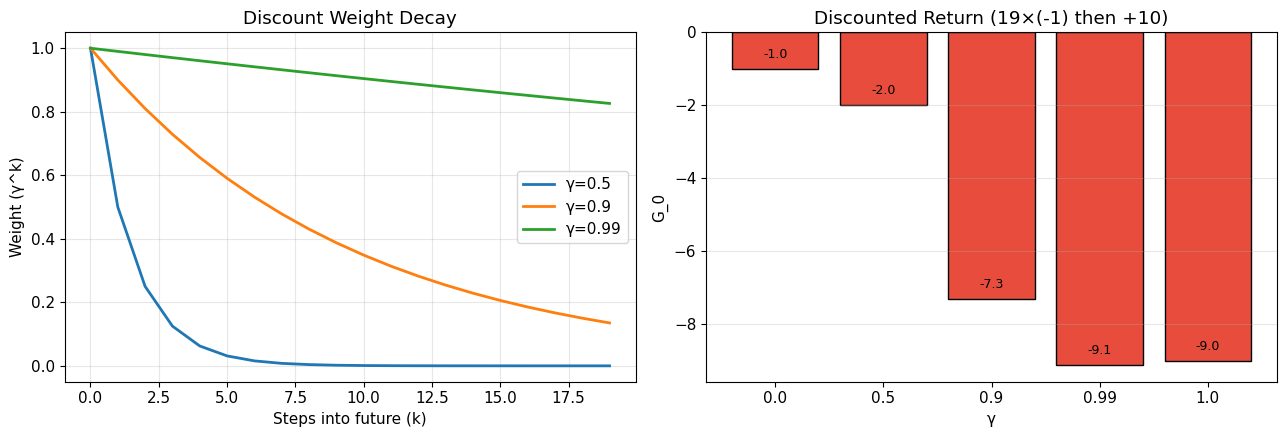

In [5]:
# 不同 gamma 对折扣回报的影响
# Effect of different gamma on discounted return

NUM_STEPS = 20
rewards_seq = [-1] * (NUM_STEPS - 1) + [10]
gamma_values = [0.0, 0.5, 0.9, 0.99, 1.0]

print(f"Rewards: {NUM_STEPS-1} steps of -1, then +10 at step {NUM_STEPS}")
print(f"\n{'Gamma':>6} | {'G_0':>8} | Interpretation")
print("-" * 50)

bar_data = {}
for g in gamma_values:
    g_return = sum(g**k * rewards_seq[k] for k in range(NUM_STEPS))
    bar_data[g] = g_return
    if g == 0: interp = "Myopic: only sees -1"
    elif g == 1: interp = "No discount: all equal"
    elif g >= 0.9: interp = "Far-sighted"
    else: interp = "Moderate"
    print(f"{g:>6.2f} | {g_return:>8.2f} | {interp}")

# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

steps = np.arange(NUM_STEPS)
for g in [0.5, 0.9, 0.99]:
    ax1.plot(steps, [g**k for k in steps], label=f'γ={g}', linewidth=2)
ax1.set_xlabel('Steps into future (k)')
ax1.set_ylabel('Weight (γ^k)')
ax1.set_title('Discount Weight Decay')
ax1.legend()
ax1.grid(True, alpha=0.3)

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in bar_data.values()]
ax2.bar([str(g) for g in bar_data], bar_data.values(), color=colors, edgecolor='black')
ax2.set_xlabel('γ')
ax2.set_ylabel('G_0')
ax2.set_title(f'Discounted Return ({NUM_STEPS-1}×(-1) then +10)')
ax2.axhline(y=0, color='black', lw=0.5)
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(bar_data.values()):
    ax2.text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 🔧 试一试
- 把 `NUM_STEPS` 改成 `5`，观察 $\gamma=0.9$ 时 G_0 的变化
- 把最后一步奖励从 `10` 改成 `100`，哪个 $\gamma$ 受影响最大？

---
## 6. Q-Learning 实战：Cliff Walking

### 简介
我们已经认识了状态、动作、策略和折扣回报。但光有概念还不够——Agent 到底怎么**学到**一个好策略？Q-Learning 就是答案：它用 Bellman 方程不断更新 Q 表，把前面所有概念串成一个完整的学习算法。

### 理论

> 📚 Argmax 详见：[Argmax 与贪婪选择](../../math/general/argmax.md)

**Q-Learning Bellman 更新：**

$$Q(s,a) \leftarrow Q(s,a) + \alpha \big[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \big]$$

| 符号 | 含义 |
|------|------|
| $\alpha$ | 学习率：新信息覆盖旧信息的程度 |
| $\gamma$ | 折扣因子：未来奖励的权重 |
| $\varepsilon$ | 探索率：随机动作的概率 |

**ε-Greedy 策略：** 以概率 $\varepsilon$ 随机探索，以概率 $1-\varepsilon$ 贪婪选择 $\arg\max_a Q(s,a)$

In [6]:
# Q-Learning on Cliff Walking
# 4x12 网格，底行有悬崖

CLIFF_ROWS, CLIFF_COLS = 4, 12
CLIFF_START, CLIFF_GOAL = (3, 0), (3, 11)
NUM_STATES = CLIFF_ROWS * CLIFF_COLS
NUM_ACTIONS = 4

# 超参数
EPISODES = 500
GAMMA = 0.9
ALPHA = 0.1
EPS_START, EPS_MIN, EPS_DECAY = 1.0, 0.01, 0.995

def to_idx(r, c): return r * CLIFF_COLS + c
def to_rc(idx): return idx // CLIFF_COLS, idx % CLIFF_COLS

def cliff_step(s, a):
    r, c = to_rc(s)
    dr, dc = ACTIONS[a]
    nr, nc = max(0, min(3, r+dr)), max(0, min(11, c+dc))
    if nr == 3 and 1 <= nc <= 10:  # 悬崖
        return to_idx(*CLIFF_START), -100, False
    ns = to_idx(nr, nc)
    if (nr, nc) == CLIFF_GOAL:
        return ns, 0, True
    return ns, -1, False

# 训练
q_table = np.zeros((NUM_STATES, NUM_ACTIONS))
ep_rewards, ep_steps = [], []
epsilon = EPS_START

for ep in range(EPISODES):
    s, done, total_r, steps = to_idx(*CLIFF_START), False, 0, 0
    while not done and steps < 1000:
        steps += 1
        a = random.choice(range(4)) if random.random() < epsilon else np.argmax(q_table[s])
        ns, r, done = cliff_step(s, a)
        total_r += r
        q_table[s][a] += ALPHA * (r + GAMMA * np.max(q_table[ns]) - q_table[s][a])
        s = ns
    ep_rewards.append(total_r)
    ep_steps.append(steps)
    epsilon = max(EPS_MIN, epsilon * EPS_DECAY)

print(f"Training complete ({EPISODES} episodes)")
print(f"  First 10 avg reward: {np.mean(ep_rewards[:10]):.1f}")
print(f"  Last  10 avg reward: {np.mean(ep_rewards[-10:]):.1f}")
print(f"  Last  10 avg steps:  {np.mean(ep_steps[-10:]):.1f}")

Training complete (500 episodes)
  First 10 avg reward: -9536.9
  Last  10 avg reward: -13.6
  Last  10 avg steps:  14.6


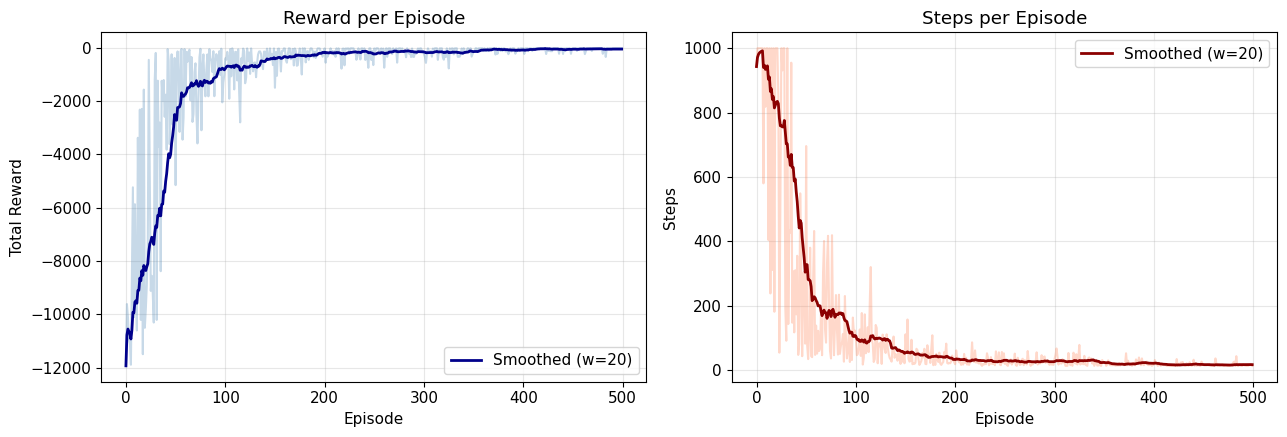

In [7]:
# 学习曲线
WINDOW = 20
def rolling(data, w):
    return [np.mean(data[max(0,i-w):i+1]) for i in range(len(data))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(ep_rewards, alpha=0.3, color='steelblue')
ax1.plot(rolling(ep_rewards, WINDOW), color='darkblue', lw=2, label=f'Smoothed (w={WINDOW})')
ax1.set_xlabel('Episode'); ax1.set_ylabel('Total Reward')
ax1.set_title('Reward per Episode'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep_steps, alpha=0.3, color='coral')
ax2.plot(rolling(ep_steps, WINDOW), color='darkred', lw=2, label=f'Smoothed (w={WINDOW})')
ax2.set_xlabel('Episode'); ax2.set_ylabel('Steps')
ax2.set_title('Steps per Episode'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

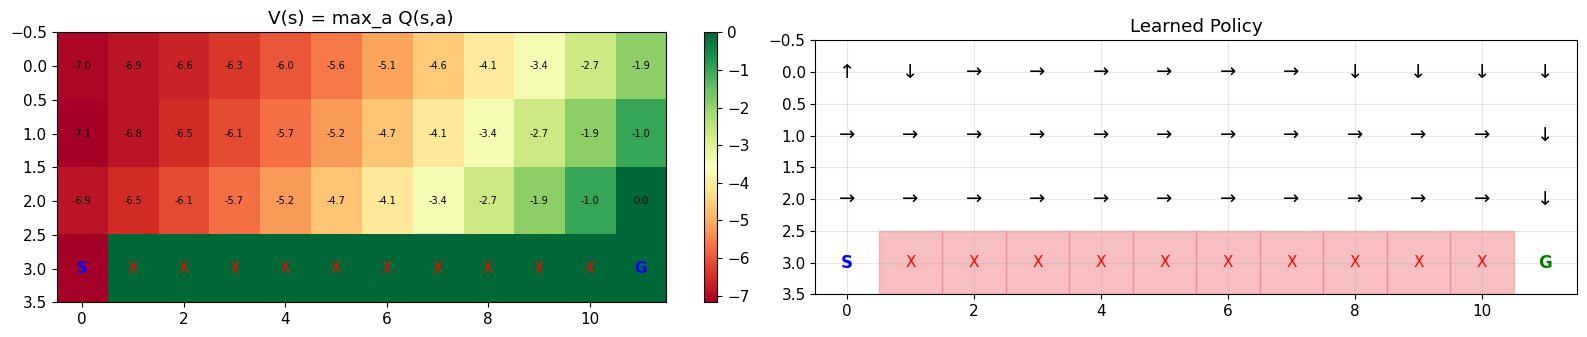

In [8]:
# 学到的策略和价值函数
ARROWS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

policy_grid = np.zeros((CLIFF_ROWS, CLIFF_COLS), dtype=int)
value_grid = np.zeros((CLIFF_ROWS, CLIFF_COLS))
for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        idx = to_idx(r, c)
        policy_grid[r,c] = np.argmax(q_table[idx])
        value_grid[r,c] = np.max(q_table[idx])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 3.5))

im = ax1.imshow(value_grid, cmap='RdYlGn', aspect='auto')
ax1.set_title('V(s) = max_a Q(s,a)'); plt.colorbar(im, ax=ax1)
for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        if (r,c) == CLIFF_START: ax1.text(c,r,'S',ha='center',va='center',fontweight='bold',color='blue')
        elif (r,c) == CLIFF_GOAL: ax1.text(c,r,'G',ha='center',va='center',fontweight='bold',color='blue')
        elif r==3 and 1<=c<=10: ax1.text(c,r,'X',ha='center',va='center',color='red')
        else: ax1.text(c,r,f'{value_grid[r,c]:.1f}',ha='center',va='center',fontsize=7)

ax2.set_xlim(-0.5, 11.5); ax2.set_ylim(3.5, -0.5)
ax2.set_title('Learned Policy'); ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)
for r in range(CLIFF_ROWS):
    for c in range(CLIFF_COLS):
        if (r,c) == CLIFF_START: ax2.text(c,r,'S',ha='center',va='center',fontsize=12,fontweight='bold',color='blue')
        elif (r,c) == CLIFF_GOAL: ax2.text(c,r,'G',ha='center',va='center',fontsize=12,fontweight='bold',color='green')
        elif r==3 and 1<=c<=10:
            ax2.add_patch(plt.Rectangle((c-0.5,r-0.5),1,1,color='lightcoral',alpha=0.5))
            ax2.text(c,r,'X',ha='center',va='center',color='red')
        else: ax2.text(c,r,ARROWS[policy_grid[r,c]],ha='center',va='center',fontsize=14)

plt.tight_layout()
plt.show()

### 🔧 试一试
- 把 `GAMMA` 改成 `0.1`（近视），观察策略变化——agent 会更冒险走悬崖边吗？
- 把 `ALPHA` 改成 `1.0`（完全替换），学习曲线会更不稳定
- 把 `EPS_DECAY` 改成 `0.9`（快速衰减），agent 会过早停止探索

---
## 7. 探索 vs 利用 (Exploration vs Exploitation)

### 简介
这是 RL **独有的**挑战（Sutton §1.1, p.3）——监督学习和无监督学习中不存在。
- **纯利用：** 只选已知最好的 → 可能错过更好的
- **纯探索：** 只尝试新的 → 浪费时间在差的选择上

      High Explore (ε=0.3 fixed): last 30 avg = -154.4
            Decaying (ε: 1→0.01): last 30 avg = -27.6
      Low Explore (ε=0.01 fixed): last 30 avg = -17.4


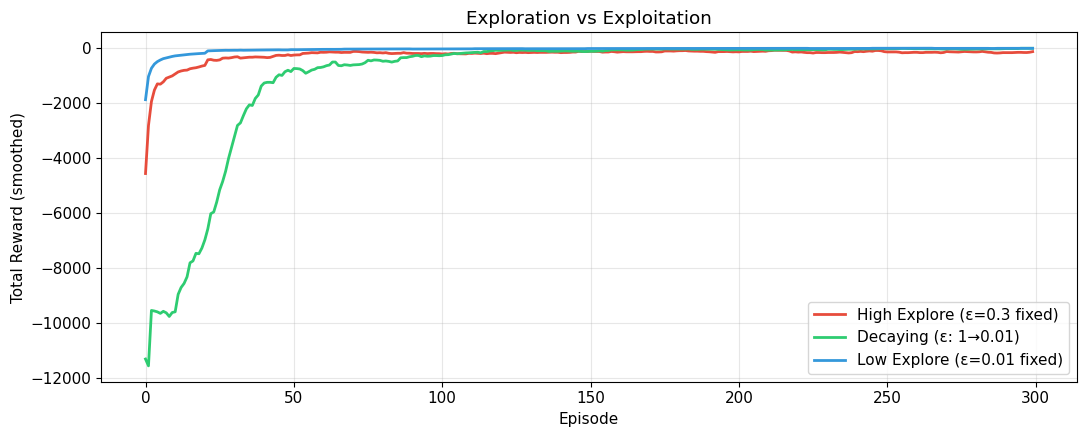

In [9]:
# 对比三种 epsilon 策略
COMP_EPISODES = 300
strategies = {
    'High Explore (ε=0.3 fixed)': (0.3, 1.0, 0.3),
    'Decaying (ε: 1→0.01)': (1.0, 0.99, 0.01),
    'Low Explore (ε=0.01 fixed)': (0.01, 1.0, 0.01),
}

results = {}
for name, (eps_s, eps_d, eps_m) in strategies.items():
    q = np.zeros((NUM_STATES, NUM_ACTIONS))
    eps = eps_s
    rlog = []
    for _ in range(COMP_EPISODES):
        s, done, er, st = to_idx(*CLIFF_START), False, 0, 0
        while not done and st < 1000:
            st += 1
            a = random.choice(range(4)) if random.random() < eps else np.argmax(q[s])
            ns, r, done = cliff_step(s, a)
            er += r
            q[s][a] += ALPHA * (r + GAMMA * np.max(q[ns]) - q[s][a])
            s = ns
        rlog.append(er)
        eps = max(eps_m, eps * eps_d)
    results[name] = rlog
    print(f"  {name:>30}: last 30 avg = {np.mean(rlog[-30:]):.1f}")

fig, ax = plt.subplots(figsize=(11, 4.5))
for (name, rlog), color in zip(results.items(), ['#e74c3c', '#2ecc71', '#3498db']):
    ax.plot(rolling(rlog, WINDOW), label=name, color=color, lw=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward (smoothed)')
ax.set_title('Exploration vs Exploitation')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 🔧 试一试
- 添加第四种策略：`ε=0.5 fixed`，它会比 `ε=0.3` 更差吗？
- 把 Decaying 的衰减率改成 `0.999`（更慢衰减），效果如何？

---
## 8. RL Agent 分类 (Agent Taxonomy)

### 简介
我们已经见过了 Q-Learning（Value Based + Model Free）和 ε-Greedy 探索策略。但 RL 的世界远不止一种算法——不同的 Agent 选择不同的组件组合。了解分类体系能帮你理解每种方法的定位。

### 理论

**按组件分：**

| 类型 | Policy | Value Function | Model |
|------|--------|---------------|-------|
| Value Based | ❌ (隐式) | ✅ | 可有可无 |
| Policy Based | ✅ | ❌ | 可有可无 |
| Actor Critic | ✅ (actor) | ✅ (critic) | 可有可无 |

**按是否有模型分：**
- **Model Free：** 无环境模型，直接从经验学习（如 Q-Learning）
- **Model Based：** 有环境模型，可以"想象"未来

**本课程 Lab 1 的 Q-Learning = Value Based + Model Free**

### 关键子问题

| 子问题 | 含义 |
|--------|------|
| Learning vs Planning | 从真实经验学 vs 从模型模拟学 |
| Exploit vs Explore | 用已知最好的 vs 尝试新的 |
| Prediction vs Control | 评估当前策略 vs 找最优策略 |

---
## 9. Prediction vs Control (Silver L1 Slides 43-45)

### 简介
RL 有两个核心子问题：
- **Prediction（预测）：** 给定策略 π，评估它有多好 → 输出 V_π(s)
- **Control（控制）：** 找到最优策略 π* → 输出 V*(s) + π*(s)

Silver 用 5×5 Gridworld 演示了两者的区别。特殊位置：A(0,1)→A'(4,1) +10, B(0,3)→B'(2,3) +5。

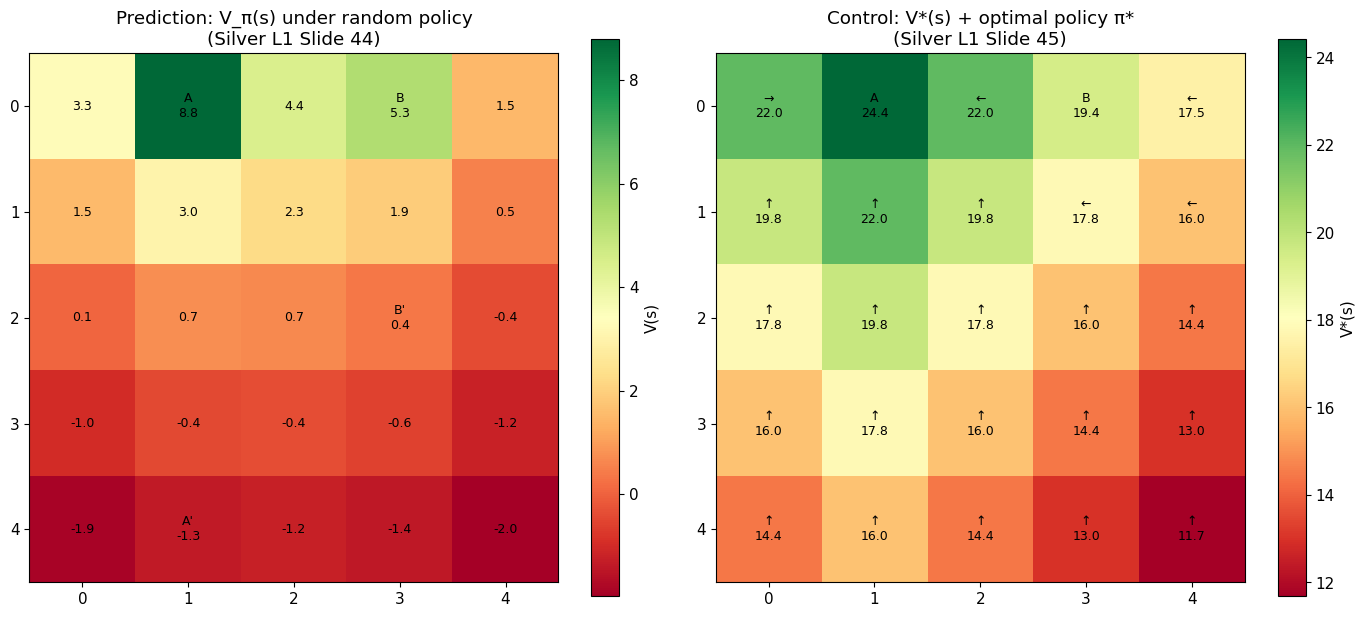

Prediction V(A) = 8.8 vs Control V*(A) = 24.4
V*(s) >= V_π(s) for ALL states — optimal is always at least as good.


In [10]:
# Prediction vs Control: Silver's 5x5 Gridworld
# 📚 Ref: David Silver L1 Slides 44-45

GRID5 = 5
GAMMA_GRID = 0.9
ACTIONS_4 = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ARROW_SYM = {0: '↑', 1: '↓', 2: '←', 3: '→'}

def grid5_step(state, action):
    r, c = state
    if (r, c) == (0, 1): return (4, 1), 10   # A → A'
    if (r, c) == (0, 3): return (2, 3), 5    # B → B'
    dr, dc = ACTIONS_4[action]
    nr, nc = r + dr, c + dc
    if nr < 0 or nr >= GRID5 or nc < 0 or nc >= GRID5:
        return (r, c), -1
    return (nr, nc), 0

# Prediction: V_π under uniform random policy
V_pred = np.zeros((GRID5, GRID5))
for _ in range(1000):
    V_new = np.zeros_like(V_pred)
    for r in range(GRID5):
        for c in range(GRID5):
            for a in range(4):
                ns, reward = grid5_step((r, c), a)
                V_new[r, c] += 0.25 * (reward + GAMMA_GRID * V_pred[ns[0], ns[1]])
    V_pred = V_new

# Control: V* under optimal policy
V_opt = np.zeros((GRID5, GRID5))
for _ in range(1000):
    V_new = np.zeros_like(V_opt)
    for r in range(GRID5):
        for c in range(GRID5):
            max_val = float('-inf')
            for a in range(4):
                ns, reward = grid5_step((r, c), a)
                max_val = max(max_val, reward + GAMMA_GRID * V_opt[ns[0], ns[1]])
            V_new[r, c] = max_val
    V_opt = V_new

# Extract optimal policy
policy_opt = np.zeros((GRID5, GRID5), dtype=int)
for r in range(GRID5):
    for c in range(GRID5):
        best_val = float('-inf')
        for a in range(4):
            ns, reward = grid5_step((r, c), a)
            val = reward + GAMMA_GRID * V_opt[ns[0], ns[1]]
            if val > best_val:
                best_val = val
                policy_opt[r, c] = a

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

im1 = ax1.imshow(V_pred, cmap='RdYlGn', aspect='equal')
ax1.set_title('Prediction: V_π(s) under random policy\n(Silver L1 Slide 44)')
plt.colorbar(im1, ax=ax1, label='V(s)')
for r in range(GRID5):
    for c in range(GRID5):
        label = f'{V_pred[r, c]:.1f}'
        if (r, c) == (0, 1): label = f'A\n{V_pred[r, c]:.1f}'
        if (r, c) == (0, 3): label = f'B\n{V_pred[r, c]:.1f}'
        if (r, c) == (4, 1): label = f"A'\n{V_pred[r, c]:.1f}"
        if (r, c) == (2, 3): label = f"B'\n{V_pred[r, c]:.1f}"
        ax1.text(c, r, label, ha='center', va='center', fontsize=9)
ax1.set_xticks(range(GRID5)); ax1.set_yticks(range(GRID5))

im2 = ax2.imshow(V_opt, cmap='RdYlGn', aspect='equal')
ax2.set_title('Control: V*(s) + optimal policy π*\n(Silver L1 Slide 45)')
plt.colorbar(im2, ax=ax2, label='V*(s)')
for r in range(GRID5):
    for c in range(GRID5):
        arrow = ARROW_SYM[policy_opt[r, c]]
        if (r, c) in [(0, 1), (0, 3)]:
            label = f'{"A" if c==1 else "B"}\n{V_opt[r, c]:.1f}'
        else:
            label = f'{arrow}\n{V_opt[r, c]:.1f}'
        ax2.text(c, r, label, ha='center', va='center', fontsize=9)
ax2.set_xticks(range(GRID5)); ax2.set_yticks(range(GRID5))

plt.tight_layout()
plt.show()

print(f"Prediction V(A) = {V_pred[0,1]:.1f} vs Control V*(A) = {V_opt[0,1]:.1f}")
print(f"V*(s) >= V_π(s) for ALL states — optimal is always at least as good.")

### 🔧 试一试
- 把 `GAMMA_GRID` 改成 `0.5`，观察 A 和 B 的价值变化——远处的奖励被折扣得更厉害
- 想想为什么 Prediction 中角落的值是负的？（提示：随机策略经常撞墙 = -1）

---
## 10. MDP vs POMDP：完全可观测 vs 部分可观测 (Silver L1 Slides 23-24)

### 简介
- **MDP（完全可观测）：** $O_t = S_t^a = S_t^e$ — agent 直接看到环境状态
- **POMDP（部分可观测）：** $O_t \neq S_t^e$ — agent 只能看到部分信息

在 POMDP 中，不同的真实状态可能产生相同的观测，导致歧义。Agent 必须自己构建状态表示。

本课程主要处理 MDP，但理解 POMDP 很重要——现实世界大多数问题都是部分可观测的。

In [11]:
# MDP vs POMDP 演示
# MDP: agent knows exact (row, col)
# POMDP: agent only observes nearby walls

GRID_P = 4

def get_wall_obs(state, grid_size=GRID_P):
    r, c = state
    return {
        'up': r == 0, 'down': r == grid_size - 1,
        'left': c == 0, 'right': c == grid_size - 1,
    }

states = [(0, 0), (0, 3), (1, 1), (1, 2), (2, 1), (2, 2)]

print("MDP: Agent knows exact state")
print("POMDP: Agent only sees wall observations\n")
print(f"{'State':>8} | {'Walls observed':>20} | {'# states with same obs'}")
print("-" * 58)

# Group states by observation
from collections import defaultdict
obs_groups = defaultdict(list)
for s in [(r, c) for r in range(GRID_P) for c in range(GRID_P)]:
    obs = get_wall_obs(s)
    walls = tuple(sorted(d for d, w in obs.items() if w))
    obs_groups[walls].append(s)

for s in states:
    obs = get_wall_obs(s)
    walls = tuple(sorted(d for d, w in obs.items() if w))
    walls_str = ', '.join(walls) if walls else 'none'
    count = len(obs_groups[walls])
    print(f"{str(s):>8} | {walls_str:>20} | {count} states share this obs")

print(f"""
Key insight:
  (1,1) and (1,2) have the SAME observation (no walls nearby).
  In POMDP, agent can't tell them apart!
  In MDP, agent knows exactly which one it's in.

  Silver L1 Slide 24 — POMDP state construction:
  1. Complete history: S_t^a = H_t
  2. Belief state: probability over possible true states
  3. RNN: learned compression of history
""")

MDP: Agent knows exact state
POMDP: Agent only sees wall observations

   State |       Walls observed | # states with same obs
----------------------------------------------------------
  (0, 0) |             left, up | 1 states share this obs
  (0, 3) |            right, up | 1 states share this obs
  (1, 1) |                 none | 4 states share this obs
  (1, 2) |                 none | 4 states share this obs
  (2, 1) |                 none | 4 states share this obs
  (2, 2) |                 none | 4 states share this obs

Key insight:
  (1,1) and (1,2) have the SAME observation (no walls nearby).
  In POMDP, agent can't tell them apart!
  In MDP, agent knows exactly which one it's in.

  Silver L1 Slide 24 — POMDP state construction:
  1. Complete history: S_t^a = H_t
  2. Belief state: probability over possible true states
  3. RNN: learned compression of history



---
## 📋 Week 1 知识检查

回答以下问题来检验你的理解：

1. RL 与监督学习的本质区别是什么？
2. 画出 Agent-Environment 交互循环图
3. 什么是马尔可夫性质？举一个满足和不满足的例子
4. $V(s)$ 和 $Q(s,a)$ 的区别是什么？
5. 为什么需要折扣因子 $\gamma$？
6. 解释 Exploitation vs Exploration 的困境
7. Q-Learning 属于哪种 Agent 类型？

> **下一站：** Week 2 — MDP 数学形式化（Bellman 方程、动态规划）
9. Prediction 和 Control 的区别是什么？各自的输入和输出是什么？
10. MDP 和 POMDP 的区别是什么？POMDP 中 agent 如何构建状态？
11. Learning 和 Planning 的区别是什么？